# Random Forest Classifier for Fake Review Detection

## 1. Introduction
Random Forest is an ensemble learning method that improves predictive accuracy and controls over-fitting by averaging multiple decision trees. In this notebook, we use precomputed TF-IDF features to train and optimize a Random Forest model.

---


## 2. Environment Setup & Data Loading

We start by importing necessary libraries, setting a seed for reproducibility, and defining paths for data and model persistence. We load the precomputed TF-IDF features and split them into training (80%) and testing (20%) sets.


In [8]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Constants
RANDOM_STATE = 42
DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
FIGURES_DIR = "../figures"

# Create directories if they don't exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Set theme for plots
sns.set_theme(style="whitegrid")

print("Loading TF-IDF features and labels...")
X = joblib.load(os.path.join(DATA_DIR, "X_tfidf.pkl"))
y = joblib.load(os.path.join(DATA_DIR, "y.pkl"))
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")


Loading TF-IDF features and labels...
Features shape: (40432, 15000)
Labels shape: (40432,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Data split successfully:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Data split successfully:
Training samples: 32345
Testing samples: 8087


## 3. Hyperparameter Tuning

We perform a randomized search over a range of hyperparameters to efficiently find the best combination for our Random Forest model.


In [10]:
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

print("Starting Hyperparameter Tuning...")
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.4f}")


Starting Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Best CV Score: 0.8804


## 4. Model Evaluation

We evaluate the optimized model on the unseen test set using accuracy and a detailed classification report.


In [11]:
y_pred = best_model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Real (OR)", "Fake (CG)"]))


Test Accuracy: 0.8917

Classification Report:

              precision    recall  f1-score   support

   Real (OR)       0.87      0.92      0.89      4044
   Fake (CG)       0.91      0.87      0.89      4043

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087



## 5. Visualizing Results

We visualize the model performance using a Confusion Matrix and by inspecting the feature importance.


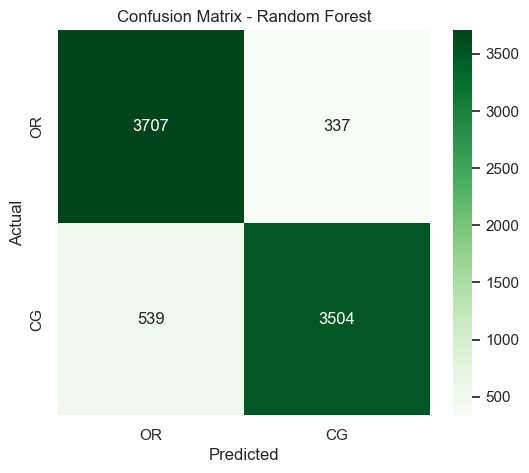

In [12]:
# 5.1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['OR', 'CG'], yticklabels=['OR', 'CG'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.savefig(os.path.join(FIGURES_DIR, "rf_confusion_matrix.png"))
plt.show()


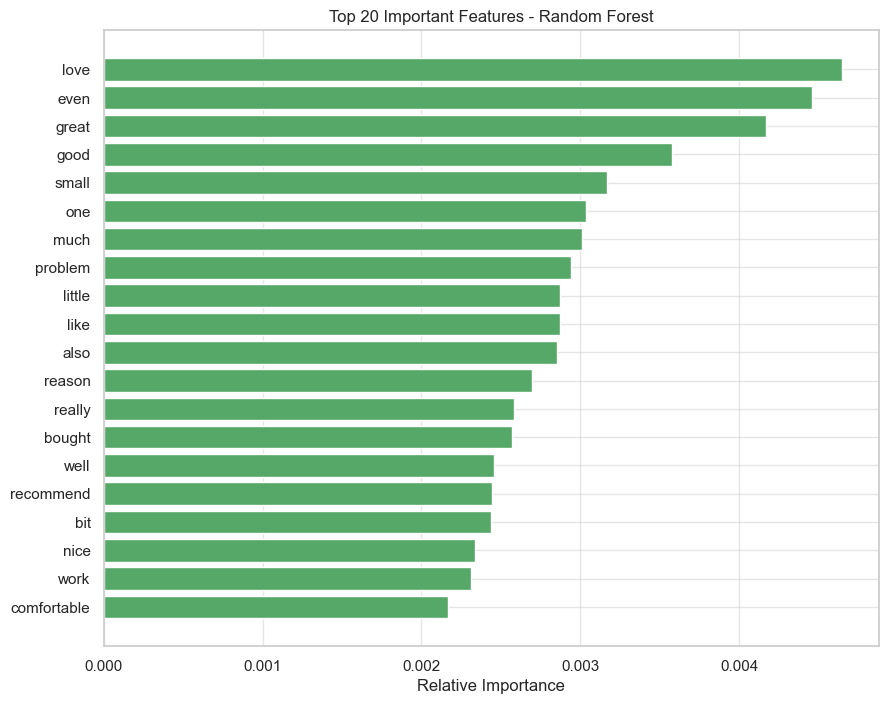

In [13]:
# 5.2. Feature Importance
vectorizer_path = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
if os.path.exists(vectorizer_path):
    vectorizer = joblib.load(vectorizer_path)
    feature_names = vectorizer.get_feature_names_out()

    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-20:]  # Top 20 features

    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices], color='g', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.title('Top 20 Important Features - Random Forest')
    plt.savefig(os.path.join(FIGURES_DIR, "rf_feature_importance.png"))
    plt.show()


## 6. Model Persistence

Finally, we save the trained model for future inference.


In [14]:
model_path = os.path.join(MODELS_DIR, "rf_model.pkl")
joblib.dump(best_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: ../models\rf_model.pkl
